# Phishing URL Detection — Model 3: Logistic Regression

Datasets:
- Primary: https://data.mendeley.com/datasets/vfszbj9b36/1
- Secondary (Kaggle): kaggle.com/datasets/sid321axn/malicious-urls-dataset

## 1. Imports

In [1]:
import json
import os
import joblib
import numpy as np
import pandas as pd
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

In [2]:
phish_df = pd.read_csv("../data/Phishing URLs.csv")
phish_df = phish_df.rename(columns={"Type": "type"})
phish_df["type"] = phish_df["type"].str.lower()

real_df = pd.read_csv("../data/URL dataset.csv")
real_df["type"] = "benign"

kaggle_df = pd.read_csv("../data/kaggle_dataset.csv")

prim_df = pd.concat([phish_df, real_df], ignore_index=True)
prim_df.loc[prim_df["type"] == "legitimate", "type"] = "benign"
prim_df = prim_df[["url", "type"]].dropna()
print(prim_df["type"].value_counts())

type
benign      450176
phishing     54807
Name: count, dtype: int64


## 3. Feature Extraction & Pipeline

In [3]:
def get_url_string(df):
    return df["url"]


def safe_urlparse(url):
    try:
        return urlparse(url)
    except ValueError:
        return urlparse("http://default.com")


def extract_url_features(df):
    urls = df["url"]
    features = pd.DataFrame()
    features["url_length"] = urls.str.len()
    features["num_dots"] = urls.str.count(r"\.")
    features["num_hyphens"] = urls.str.count(r"-")
    features["num_slashes"] = urls.str.count(r"/")
    features["num_digits"] = urls.str.count(r"\d")
    features["num_special_chars"] = urls.str.count(r"[@_!#$%^&*()<>?|}{~:]")
    features["has_https"] = urls.str.startswith("https").astype(int)
    features["has_ip"] = urls.str.contains(
        r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}"
    ).astype(int)
    features["has_at_symbol"] = urls.str.contains("@").astype(int)
    features["subdomain_count"] = urls.apply(
        lambda u: len(safe_urlparse(u).netloc.split(".")) - 2
    )
    features["path_length"] = urls.apply(lambda u: len(safe_urlparse(u).path))
    features["query_length"] = urls.apply(lambda u: len(safe_urlparse(u).query))
    return features


X = prim_df[["url"]]
y = prim_df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline(
    [
        (
            "features",
            FeatureUnion(
                [
                    (
                        "tfidf",
                        Pipeline(
                            [
                                ("get_text", FunctionTransformer(get_url_string)),
                                (
                                    "vec",
                                    TfidfVectorizer(
                                        analyzer="char_wb",
                                        ngram_range=(3, 5),
                                        max_features=5000,
                                    ),
                                ),
                            ]
                        ),
                    ),
                    (
                        "handcrafted",
                        Pipeline(
                            [
                                (
                                    "get_feats",
                                    FunctionTransformer(extract_url_features),
                                ),
                            ]
                        ),
                    ),
                ]
            ),
        ),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="saga",
                C=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

/opt/miniconda3/envs/geo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/envs/geo/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 4. Primary Dataset Evaluation

In [4]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
primary_roc_auc = roc_auc_score((y_test == "phishing").astype(int), y_proba)

print("=" * 50)
print("LOGISTIC REGRESSION — PRIMARY DATASET")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {primary_roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["benign", "phishing"])
fn = cm[1][0]
tp = cm[1][1]
fn_rate = fn / (fn + tp)
phish_recall = tp / (tp + fn)
print(f"Phishing missed (FN rate): {fn_rate:.2%}")

LOGISTIC REGRESSION — PRIMARY DATASET
Accuracy:  0.7555
Precision: 0.8773
Recall:    0.7555
F1-Score:  0.7969
ROC-AUC:   0.8045

              precision    recall  f1-score   support

      benign       0.95      0.76      0.85     90036
    phishing       0.26      0.69      0.38     10961

    accuracy                           0.76    100997
   macro avg       0.61      0.72      0.61    100997
weighted avg       0.88      0.76      0.80    100997

Phishing missed (FN rate): 31.40%


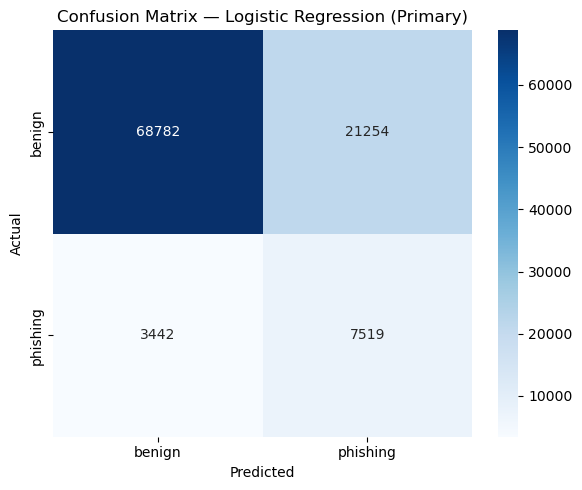

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "phishing"],
    yticklabels=["benign", "phishing"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Logistic Regression (Primary)")
plt.tight_layout()
os.makedirs("../output/visualizations", exist_ok=True)
plt.savefig("../output/visualizations/lr_confusion_matrix.png", dpi=150)
plt.show()

## 6. Generalisation — Kaggle Dataset

In [7]:
second_df = kaggle_df[kaggle_df["type"].isin(["benign", "phishing"])].copy()
second_df["type"] = second_df["type"].str.lower()

X_second = second_df[["url"]]
y_second = second_df["type"]
y_second_pred = pipeline.predict(X_second)

accuracy_second = accuracy_score(y_second, y_second_pred)
precision_second = precision_score(
    y_second, y_second_pred, average="weighted", zero_division=0
)
recall_second = recall_score(
    y_second, y_second_pred, average="weighted", zero_division=0
)
f1_second = f1_score(y_second, y_second_pred, average="weighted", zero_division=0)

print("=" * 50)
print("LOGISTIC REGRESSION — KAGGLE GENERALISATION")
print("=" * 50)
print(f"Accuracy:  {accuracy_second:.4f}")
print(f"Precision: {precision_second:.4f}")
print(f"Recall:    {recall_second:.4f}")
print(f"F1-Score:  {f1_second:.4f}")
print()
print(classification_report(y_second, y_second_pred, zero_division=0))
print("\nPredicted distribution:")
print(pd.Series(y_second_pred).value_counts(normalize=True))
print("\nActual distribution:")
print(y_second.value_counts(normalize=True))

LOGISTIC REGRESSION — KAGGLE GENERALISATION
Accuracy:  0.7948
Precision: 0.7357
Recall:    0.7948
F1-Score:  0.7540

              precision    recall  f1-score   support

      benign       0.83      0.94      0.88    428103
    phishing       0.31      0.11      0.17     94111

    accuracy                           0.79    522214
   macro avg       0.57      0.53      0.53    522214
weighted avg       0.74      0.79      0.75    522214


Predicted distribution:
benign      0.933859
phishing    0.066141
Name: proportion, dtype: float64

Actual distribution:
type
benign      0.819785
phishing    0.180215
Name: proportion, dtype: float64


## 7. Save Metrics

In [8]:
os.makedirs("../output", exist_ok=True)

results = {
    "primary": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "phish_recall": float(phish_recall),
        "f1": float(f1),
        "roc_auc": float(primary_roc_auc),
        "confusion_matrix": cm.tolist(),
        "fn_rate": float(fn_rate),
    },
    "kaggle": {
        "accuracy": float(accuracy_second),
        "precision": float(precision_second),
        "recall": float(recall_second),
        "f1": float(f1_second),
    },
}

with open("../output/lr_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved → output/lr_results.json")

Saved → output/lr_results.json


## 8. Save Model

In [9]:
os.makedirs("../output/models", exist_ok=True)
joblib.dump(pipeline, "../output/models/lr_pipeline.joblib")
print("Saved → output/models/lr_pipeline.joblib")

Saved → output/models/lr_pipeline.joblib
